In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

[255 255 255 255 255 255 255 255 255 255  75  71  67  62  56  50  43  42
  49  56  63  52  40  28  22  18  15  14  20  25  30  25  19  13  10  10
  10  21  54  88 255 255 255 255 255 255 255 255 255 255 255]
[255 255 255 255 255 255 255 255 244 199 130  82  66  62  56  50  46  45
  50  55  56  51  40  30  23  18  16  16  20  24  26  24  19  14  11  11
  16  30  64 128 201 245 255 255 255 255 255 255 255 255 255]
[255 255 255 255 255 255 252 243 222 185 141 103  78  64  56  51  49  48
  50  52  51  47  40  32  25  21  18  18  20  22  23  22  19  16  14  16
  26  47  83 132 183 222 243 252 255 255 255 255 255 255 255]


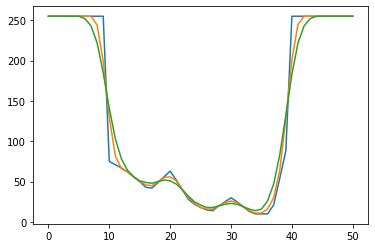

In [13]:
img = cv.imread("../images/small2.png", 0)

blur = cv.GaussianBlur(img, (5, 5), 0)
blur2 = cv.GaussianBlur(img, (9, 9), 0)

print(img[11])
print(blur[11])
print(blur2[11])

plt.plot(img[11])
plt.plot(blur[11])
plt.plot(blur2[11])

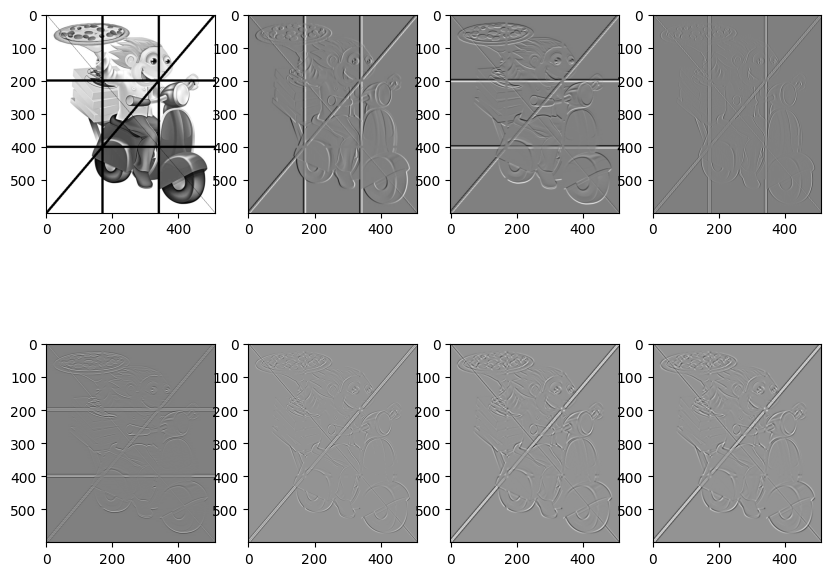

In [35]:
img = cv.imread("../images/xiaoren.png", 0)
rows, cols = img.shape

cv.line(img, (0, rows // 3), (cols, rows // 3), 0, 5)
cv.line(img, (0, 2 * rows // 3), (cols, 2 * rows // 3), 0, 5)
cv.line(img, pt1=(cols // 3, 0), pt2=(cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(2 * cols // 3, 0), pt2=(2 * cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(0, 0), pt2=(cols, rows), color=0, thickness=1)
cv.line(img, pt1=(cols, 0), pt2=(0, rows), color=0, thickness=5)

sobelx = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=5)
sobely = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=5)

sobelx2 = cv.Sobel(img, cv.CV_64F, 2, 0, ksize=5)
sobely2 = cv.Sobel(img, cv.CV_64F, 0, 2, ksize=5)

sobel = cv.Sobel(img, cv.CV_64F, 1, 1, ksize=5)

sobelx_y = cv.Sobel(sobelx, cv.CV_64F, 0, 1, ksize=5)
sobely_x = cv.Sobel(sobely, cv.CV_64F, 1, 0, ksize=5)

fig, axex = plt.subplots(2, 4, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img, cmap='gray')
axex[0, 1].imshow(sobelx, cmap='gray')
axex[0, 2].imshow(sobely, cmap='gray')
axex[0, 3].imshow(sobelx2, cmap='gray')
axex[1, 0].imshow(sobely2, cmap='gray')
axex[1, 1].imshow(sobel, cmap='gray')
axex[1, 2].imshow(sobelx_y, cmap='gray')
axex[1, 3].imshow(sobely_x, cmap='gray')
plt.show()

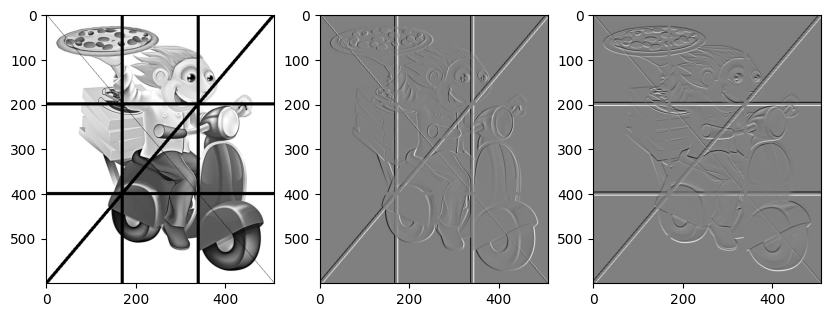

In [37]:
kernel = np.asarray([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

sobely = cv.filter2D(img, cv.CV_64F, kernel)
sobelx = cv.filter2D(img, cv.CV_64F, kernel.T)

fig, axex = plt.subplots(1, 3, figsize=(10, 8), dpi=100)
axex[0].imshow(img, cmap='gray')
axex[1].imshow(sobelx, cmap='gray')
axex[2].imshow(sobely, cmap='gray')
plt.show()

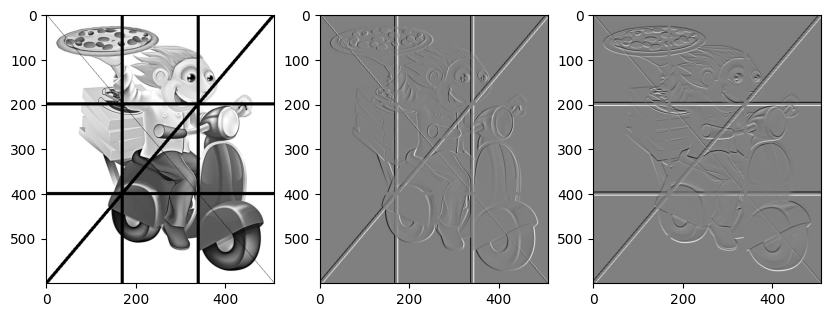

In [39]:
kernel = np.asarray([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])
kernel1 = np.asarray([[1, 2, 1]])  # 水平
kernel2 = np.asarray([[-1],
                      [0],
                      [1]])
# img_blur = cv.filter2D(img, cv.CV_64F, kernel1.T)
# sobelx = cv.filter2D(img_blur, cv.CV_64F, kernel2.T)
sobelx = cv.filter2D(img, cv.CV_64F, kernel.T)

# img_blur = cv.filter2D(img, cv.CV_64F, kernel1)     # 水平高斯平滑
# sobely = cv.filter2D(img_blur, cv.CV_64F, kernel2)  # 垂直梯度
sobely = cv.filter2D(img, cv.CV_64F, kernel)

fig, axex = plt.subplots(1, 3, figsize=(10, 8), dpi=100)
axex[0].imshow(img, cmap='gray')
axex[1].imshow(sobelx, cmap='gray')
axex[2].imshow(sobely, cmap='gray')
plt.show()

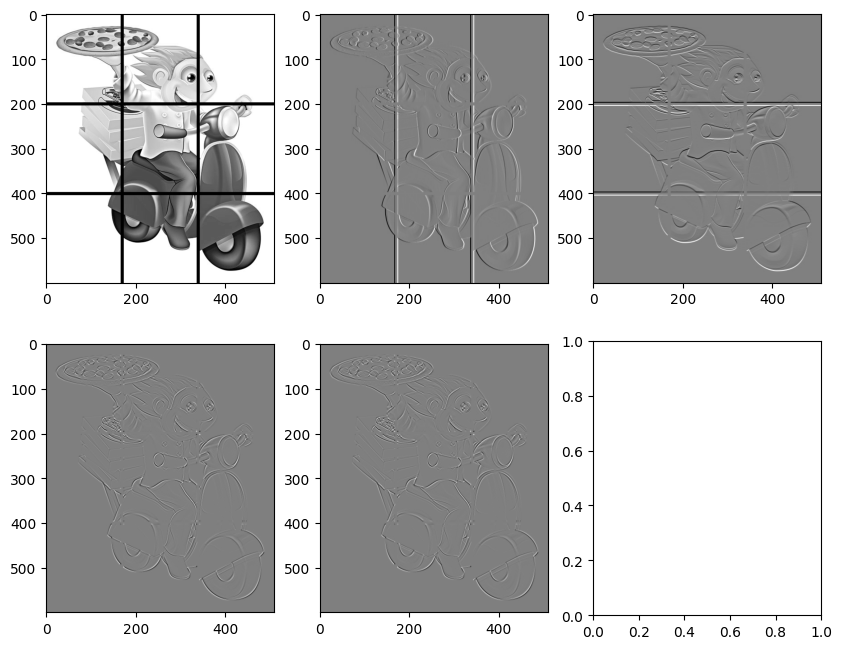

In [44]:
img = cv.imread('../images/xiaoren.png', 0)

rows, cols = img.shape
cv.line(img, pt1=(0, rows // 3), pt2=(cols, rows // 3), color=0, thickness=5)
cv.line(img, pt1=(0, 2 * rows // 3), pt2=(cols, 2 * rows // 3), color=0, thickness=5)
cv.line(img, pt1=(cols // 3, 0), pt2=(cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(2 * cols // 3, 0), pt2=(2 * cols // 3, rows), color=0, thickness=5)

scharr_x = cv.Scharr(img, cv.CV_64F, 1, 0)
scharr_y = cv.Scharr(img, cv.CV_64F, 0, 1)

scharr_x_y = cv.Scharr(scharr_x, cv.CV_64F, 0, 1)
scharr_y_x = cv.Scharr(scharr_y, cv.CV_64F, 1, 0)

fig, axex = plt.subplots(2, 3, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img, cmap='gray')
axex[0, 1].imshow(scharr_x, cmap='gray')
axex[0, 2].imshow(scharr_y, cmap='gray')
axex[1, 0].imshow(scharr_x_y, cmap='gray')
axex[1, 1].imshow(scharr_y_x, cmap='gray')
plt.show()

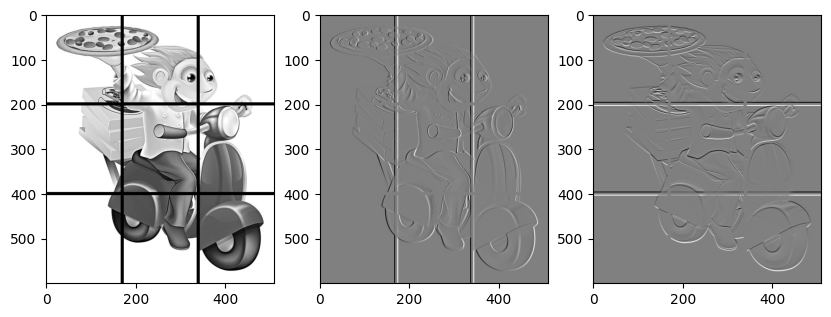

In [45]:
kernel = np.asarray([
    [-3, -10, -3],
    [0, 0, 0],
    [3, 10, 3]
])

scharr_y = cv.filter2D(img, cv.CV_64F, kernel)
scharr_x = cv.filter2D(img, cv.CV_64F, kernel.T)

fig, axex = plt.subplots(1, 3, figsize=(10, 8), dpi=100)
axex[0].imshow(img, cmap='gray')
axex[1].imshow(scharr_x, cmap='gray')
axex[2].imshow(scharr_y, cmap='gray')
plt.show()

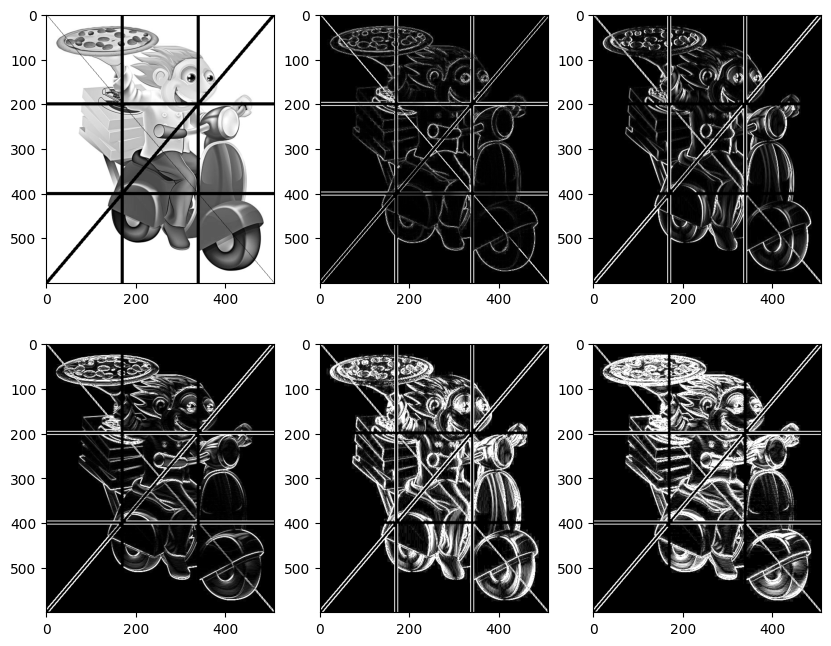

In [52]:
img = cv.imread('../images/xiaoren.png', 0)

# 画几条线
rows, cols = img.shape
cv.line(img, pt1=(0, rows // 3), pt2=(cols, rows // 3), color=0, thickness=5)
cv.line(img, pt1=(0, 2 * rows // 3), pt2=(cols, 2 * rows // 3), color=0, thickness=5)
cv.line(img, pt1=(cols // 3, 0), pt2=(cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(2 * cols // 3, 0), pt2=(2 * cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(0, 0), pt2=(cols, rows), color=0, thickness=1)
cv.line(img, pt1=(cols, 0), pt2=(0, rows), color=0, thickness=5)

ksize = 3

laplacian = cv.Laplacian(img, cv.CV_64F, ksize)
laplacian = cv.convertScaleAbs(laplacian)

sobel_x = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=ksize)
sobel_x = cv.convertScaleAbs(sobel_x)

sobel_y = cv.Sobel(img, cv.CV_64F, dx=0, dy=1, ksize=ksize)  # 提取边缘信息（水平）
sobel_y = cv.convertScaleAbs(sobel_y)

scharr_x = cv.Scharr(img, cv.CV_64F, dx=1, dy=0)  # 提取边缘信息（垂直）
scharr_x = cv.convertScaleAbs(scharr_x)

scharr_y = cv.Scharr(img, cv.CV_64F, dx=0, dy=1)  # 提取边缘信息（水平）
scharr_y = cv.convertScaleAbs(scharr_y)

fig, axex = plt.subplots(2, 3, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img, cmap='gray')
axex[0, 1].imshow(laplacian, cmap='gray')
axex[0, 2].imshow(sobel_x, cmap='gray')
axex[1, 0].imshow(sobel_y, cmap='gray')
axex[1, 1].imshow(scharr_x, cmap='gray')
axex[1, 2].imshow(scharr_y, cmap='gray')
plt.show()

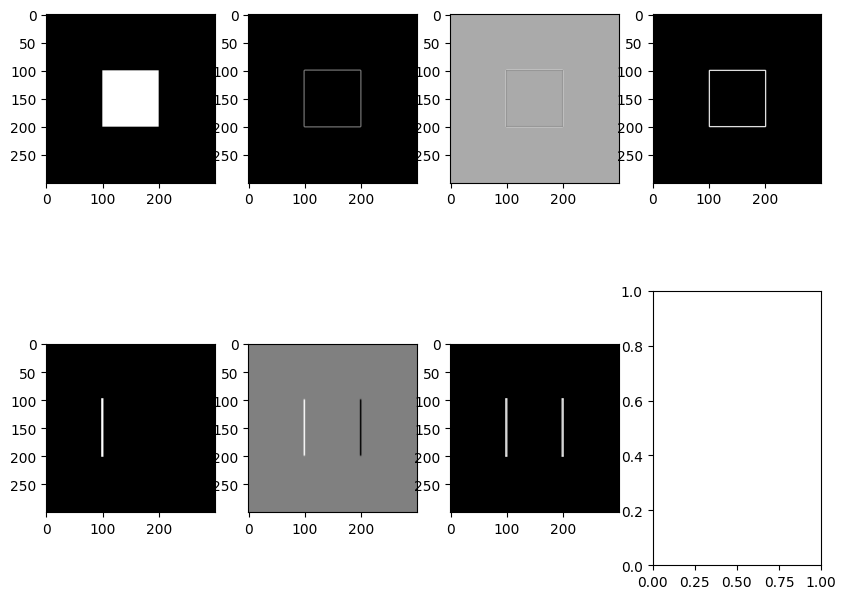

In [58]:
img = np.zeros((300, 300), np.uint8)
img[100:200, 100:200] = 255

ksize = 5

dst1 = cv.Laplacian(img, cv.CV_8U, ksize)
dst2 = cv.Laplacian(img, cv.CV_64F, ksize)
dst3 = np.uint8(np.absolute(dst2))

dst4 = cv.Sobel(img, cv.CV_8U, 1, 0, ksize=ksize)
dst5 = cv.Sobel(img, cv.CV_64F, dx=1, dy=0, ksize=ksize)

dst6 = np.uint8(np.absolute(dst5))

fig, axex = plt.subplots(2, 4, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img, cmap='gray')
axex[0, 1].imshow(dst1, cmap='gray')
axex[0, 2].imshow(dst2, cmap='gray')
axex[0, 3].imshow(dst3, cmap='gray')
axex[1, 0].imshow(dst4, cmap='gray')
axex[1, 1].imshow(dst5, cmap='gray')
axex[1, 2].imshow(dst6, cmap='gray')
plt.show()

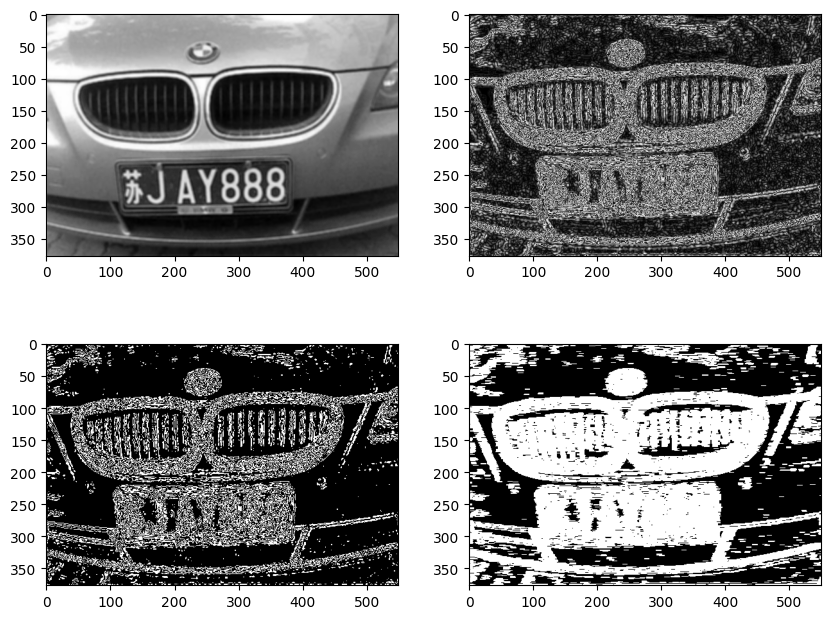

In [67]:
img = cv.imread("../images/car.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img = cv.GaussianBlur(img, (5, 5), 2)

img1 = cv.Laplacian(img, cv.CV_64F, ksize=5)
img1 = np.uint8(np.absolute(img1))

ret, img2 = cv.threshold(img1, 127, 255, cv.THRESH_BINARY)

kernel = np.asarray([
    [1, 1, 1, 1, 1, 1, 1, 1]
])
img3 = cv.dilate(img2, kernel, 4)

fig, axex = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img, cmap='gray')
axex[0, 1].imshow(img1, cmap='gray')
axex[1, 0].imshow(img2, cmap='gray')
axex[1, 1].imshow(img3, cmap='gray')
plt.show()

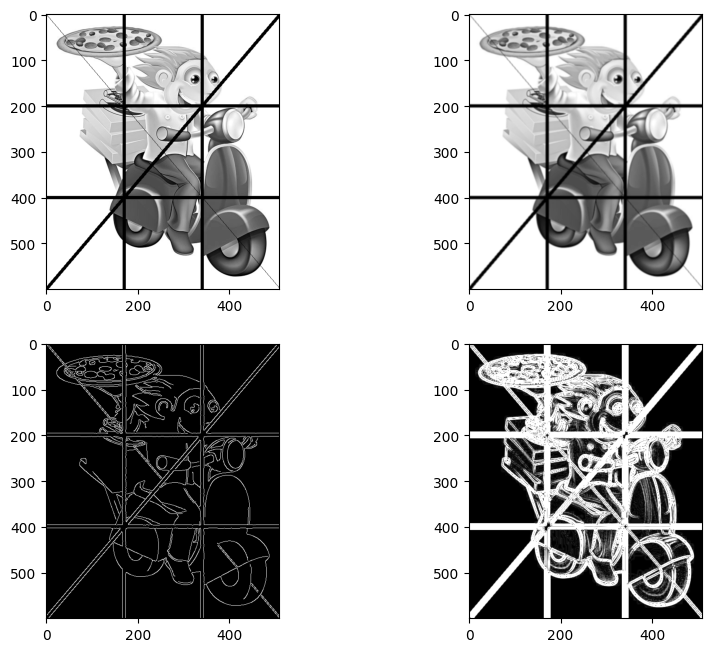

In [73]:
img = cv.imread('../images/xiaoren.png', 0)

rows, cols = img.shape
cv.line(img, pt1=(0, rows // 3), pt2=(cols, rows // 3), color=0, thickness=5)
cv.line(img, pt1=(0, 2 * rows // 3), pt2=(cols, 2 * rows // 3), color=0, thickness=5)
cv.line(img, pt1=(cols // 3, 0), pt2=(cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(2 * cols // 3, 0), pt2=(2 * cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(0, 0), pt2=(cols, rows), color=0, thickness=1)
cv.line(img, pt1=(cols, 0), pt2=(0, rows), color=0, thickness=5)

blur = cv.GaussianBlur(img, (5, 5), 0)

edges = cv.Canny(blur, 50, 250)

laplacian = cv.Laplacian(blur, cv.CV_64F, ksize=5)
laplacian = cv.convertScaleAbs(laplacian)

fig, axex = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img, cmap='gray')
axex[0, 1].imshow(blur, cmap='gray')
axex[1, 0].imshow(edges, cmap='gray')
axex[1, 1].imshow(laplacian, cmap='gray')
plt.show()

In [74]:
bgr_xiaoren = cv.cvtColor(edges, cv.COLOR_BGR2RGB)
cv.rectangle(bgr_xiaoren, (243, 243), (253, 253), (0, 0, 255), thickness=2)

cv.imshow('bgr_xiaoren', bgr_xiaoren)
cv.waitKey(0)
cv.destroyAllWindows()

In [76]:
blur[243:253, 243:253]

array([[188, 190, 192, 194, 197, 201, 204, 206, 207, 208],
       [188, 190, 192, 195, 198, 200, 199, 194, 189, 185],
       [189, 191, 193, 195, 191, 180, 165, 150, 138, 133],
       [190, 192, 191, 181, 159, 134, 113, 100,  94,  94],
       [191, 189, 174, 144, 113,  93,  88,  91,  96, 103],
       [188, 171, 138, 104,  89,  92, 104, 116, 126, 132],
       [173, 138, 104,  91, 100, 116, 130, 140, 146, 150],
       [146, 108,  93, 106, 125, 139, 146, 151, 154, 156],
       [119,  96, 106, 128, 144, 151, 155, 157, 160, 162],
       [104, 104, 128, 146, 154, 158, 161, 163, 165, 167]], dtype=uint8)

In [77]:
edges[243:253, 243:253]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0, 255, 255, 255, 255],
       [  0,   0,   0,   0, 255, 255,   0,   0,   0,   0],
       [  0,   0, 255, 255, 255,   0,   0,   0,   0,   0],
       [  0, 255, 255,   0,   0,   0,   0, 255, 255, 255],
       [255, 255,   0,   0,   0, 255, 255,   0,   0,   0],
       [255,   0,   0,   0, 255, 255,   0,   0,   0,   0],
       [255,   0,   0, 255,   0,   0,   0,   0,   0,   0],
       [  0,   0, 255, 255,   0,   0,   0,   0,   0,   0]], dtype=uint8)

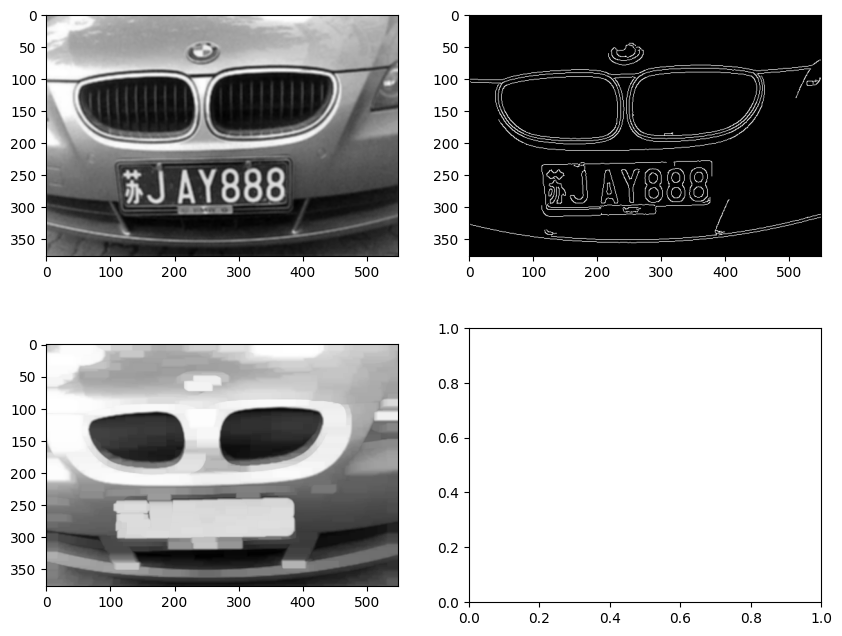

In [83]:
img = cv.imread("../images/car.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img = cv.GaussianBlur(img, (5, 5), 2)

img1 = cv.Canny(img, 50, 250)

kernel = np.asarray([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
])
img2 = cv.dilate(img, kernel, iterations=8)

fig, axex = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img, cmap='gray')
axex[0, 1].imshow(img1, cmap='gray')
axex[1, 0].imshow(img2, cmap='gray')
plt.show()

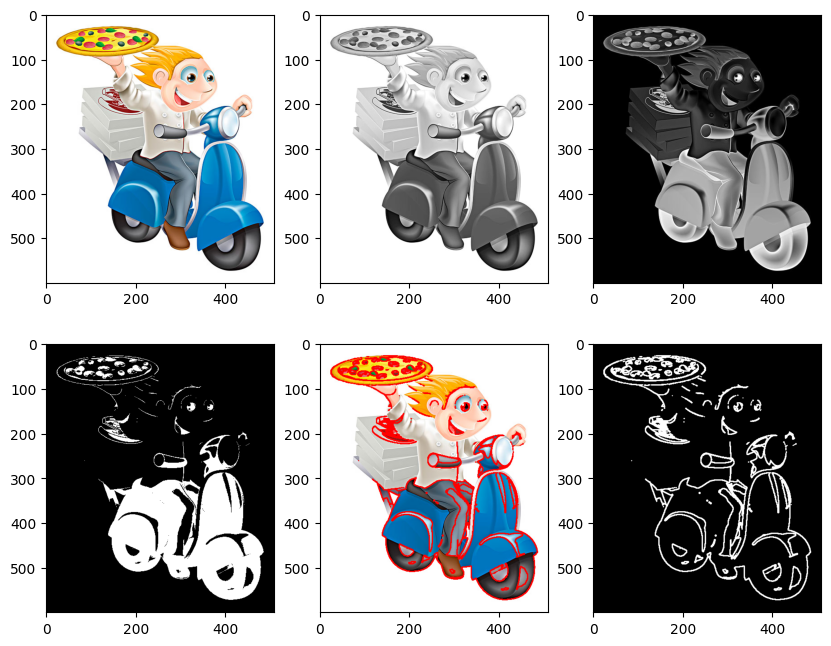

In [102]:
img = cv.imread('../images/xiaoren.png')

img1 = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

img2 = cv.bitwise_not(img1)

ret, thresh = cv.threshold(img2, 127, 255, cv.THRESH_BINARY)

contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_NONE)

img3 = np.copy(img)
cv.drawContours(img3, contours, -1, (0, 0, 255), 2)

img4 = np.zeros_like(img3)
cv.drawContours(img4, contours, -1, (255, 255, 255), 2)

fig, axex = plt.subplots(2, 3, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img[:, :, ::-1])
axex[0, 1].imshow(img1, cmap='gray')
axex[0, 2].imshow(img2, cmap='gray')
axex[1, 0].imshow(thresh, cmap='gray')
axex[1, 1].imshow(img3[:, :, ::-1])
axex[1, 2].imshow(img4[:, :, ::-1])
plt.show()

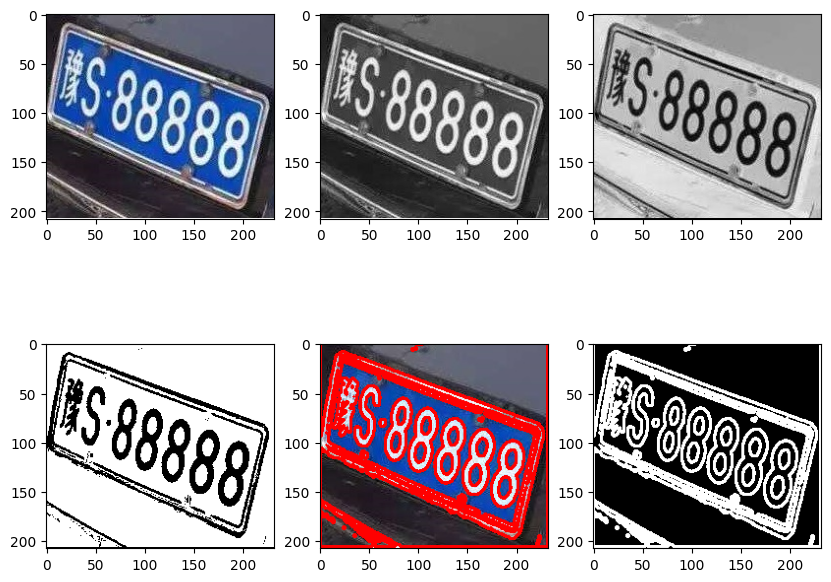

In [106]:
img = cv.imread("../images/car3_plat.jpg")

img1 = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

img2 = cv.bitwise_not(img1)

ret, thresh = cv.threshold(img2, 127, 255, cv.THRESH_BINARY)

contours, hierarchy = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)

img3 = np.copy(img)
cv.drawContours(img3, contours, -1, (0, 0, 255), 2)

img4 = np.zeros_like(img3)
cv.drawContours(img4, contours, -1, (255, 255, 255), 2)

fig, axex = plt.subplots(2, 3, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img[:, :, ::-1])
axex[0, 1].imshow(img1, cmap='gray')
axex[0, 2].imshow(img2, cmap='gray')
axex[1, 0].imshow(thresh, cmap='gray')
axex[1, 1].imshow(img3[:, :, ::-1])
axex[1, 2].imshow(img4[:, :, ::-1])
plt.show()

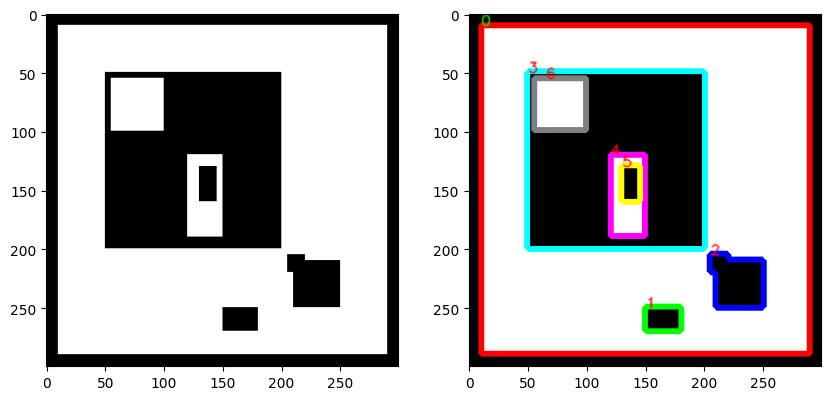

In [115]:
import copy

img = np.zeros((300, 300), np.uint8)
img[10:290, 10:290] = 255
img[50:200, 50:200] = 0
img[55:100, 55:100] = 255
img[120:190, 120:150] = 255
img[130:160, 130:145] = 0
img[210:250, 210:250] = 0
img[250:270, 150:180] = 0
img[205:220, 205:220] = 0

img1 = np.copy(img)  # 拷贝图像

ret, thresh = cv.threshold(img1, 127, 255, cv.THRESH_BINARY)

contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

bgr_img = cv.cvtColor(img, cv.COLOR_GRAY2BGR)

cv.drawContours(bgr_img, contours, contourIdx=0, color=[255, 0, 0], thickness=3)  # 0红色
cv.drawContours(bgr_img, contours, contourIdx=1, color=[0, 255, 0], thickness=3)  # 1绿色
cv.drawContours(bgr_img, contours, contourIdx=2, color=[0, 0, 255], thickness=3)  # 2蓝色
cv.drawContours(bgr_img, contours, contourIdx=3, color=[0, 255, 255], thickness=3)  # 3青色
cv.drawContours(bgr_img, contours, contourIdx=4, color=[255, 0, 255], thickness=3)  # 4紫色
cv.drawContours(bgr_img, contours, contourIdx=5, color=[255, 255, 0], thickness=3)  # 5黄色
cv.drawContours(bgr_img, contours, contourIdx=6, color=[128, 128, 128], thickness=3)  # 6灰色

cv.putText(bgr_img, text='0', org=(10, 10), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(0, 255, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='1', org=(150, 250), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='2', org=(205, 205), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='3', org=(50, 50), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='4', org=(120, 120), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='5', org=(130, 130), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='6', org=(65, 55), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)

fig, axex = plt.subplots(1, 2, figsize=(10, 8), dpi=100)
axex[0].imshow(img, cmap='gray')
axex[1].imshow(bgr_img, cmap='gray')
plt.show()

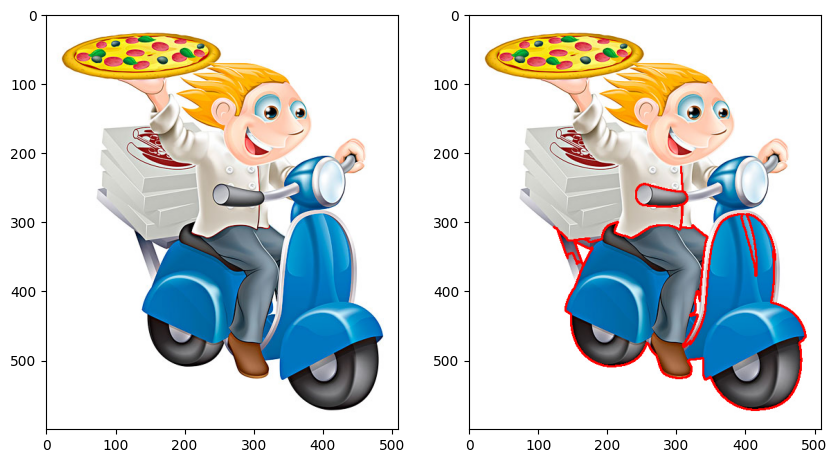

65960.5
2487.3636897802353


In [126]:
img = cv.imread('../images/xiaoren.png')
img1 = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img1 = cv.bitwise_not(img1)
ret, thresh = cv.threshold(img1, 127, 255, cv.THRESH_BINARY)
contours, hierarchy = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)

idx = np.argmax([len(t) for t in contours])
cnt = contours[idx]

img2 = np.copy(img)
cv.drawContours(img2, contours, idx, (0, 0, 255), 2)

fig, axex = plt.subplots(1, 2, figsize=(10, 8), dpi=100)
axex[0].imshow(img[:, :, ::-1])
axex[1].imshow(img2[:, :, ::-1])
plt.show()

area = cv.contourArea(cnt)
perimeter = cv.arcLength(cnt, True)
print(area)
print(perimeter)

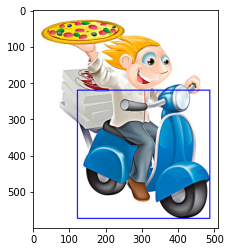

In [131]:
x, y, w, h = cv.boundingRect(cnt)
cv.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
plt.imshow(img[:, :, ::-1])
plt.show()

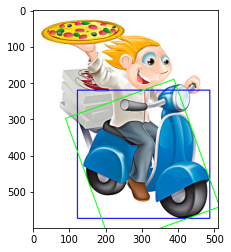

In [135]:
rect = cv.minAreaRect(cnt)

box = cv.boxPoints(rect)
box = np.int64(box)

cv.drawContours(img, [box], 0, (0, 255, 0), 2)

plt.imshow(img[:, :, ::-1])
plt.show()

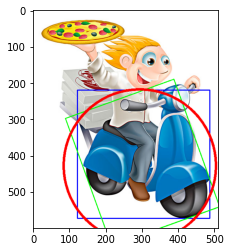

In [136]:
(x, y), radius = cv.minEnclosingCircle(cnt)
center = (int(x), int(y))
radius = int(radius)
cv.circle(img, center, radius, (0, 0, 255), 5)
plt.imshow(img[:, :, ::-1])
plt.show()

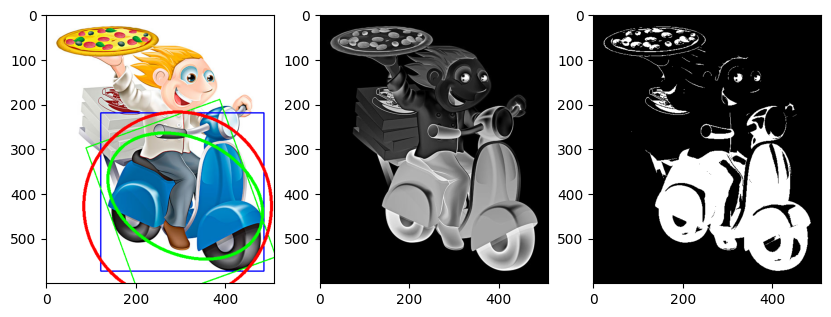

In [139]:
ellipse = cv.fitEllipse(cnt)
cv.ellipse(img, ellipse, (0, 255, 0), 5)
fig, axex = plt.subplots(1, 3, figsize=(10, 8), dpi=100)
axex[0].imshow(img[:, :, ::-1])
axex[1].imshow(img1, cmap='gray')
axex[2].imshow(thresh, cmap='gray')
plt.show()

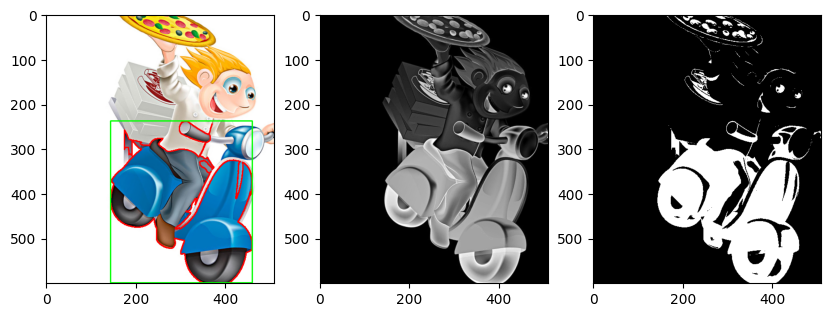

In [142]:
img = cv.imread('../images/xiaoren.png')

rect = [(302, 420), (372, 317), -20]

M = cv.getRotationMatrix2D(rect[0], rect[-1], 1)
rows, cols = img[:, :, 0].shape

img = cv.warpAffine(img, M, (cols, rows), borderValue=[255, 255, 255])

img1 = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img1 = cv.bitwise_not(img1)
ret, thresh = cv.threshold(img1, 127, 255, cv.THRESH_BINARY)
contours, hierarchy = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)

idx = np.argmax([len(t) for t in contours])
cnt = contours[idx]
cv.drawContours(img, contours, contourIdx=idx, color=(0, 0, 255), thickness=2)

rect = cv.minAreaRect(cnt)
box = cv.boxPoints(rect)
box = np.int64(box)
cv.drawContours(img, [box], 0, (0, 255, 0), 2)

fig, axex = plt.subplots(1, 3, figsize=(10, 8), dpi=100)
axex[0].imshow(img[:, :, ::-1])
axex[1].imshow(img1, cmap='gray')
axex[2].imshow(thresh, cmap='gray')
plt.show()

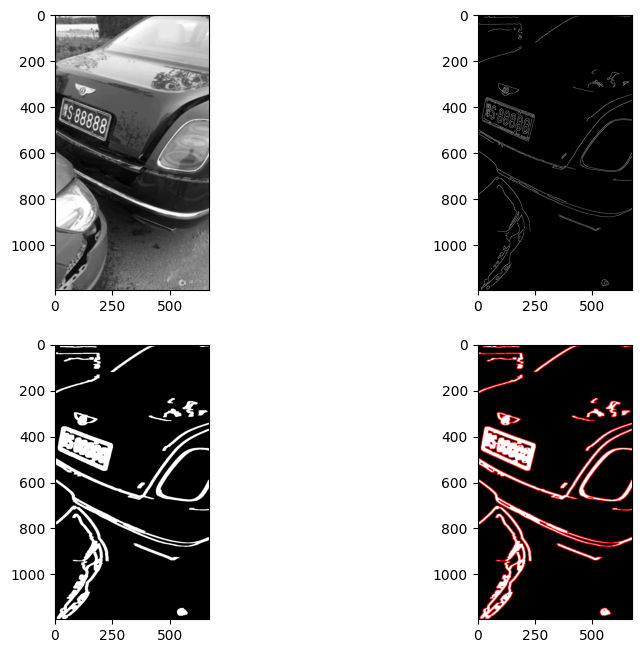

In [157]:
img = cv.imread("../images/car3.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img = cv.GaussianBlur(img, (5, 5), 2)

img1 = cv.Canny(img, 50, 250)

kernel = np.asarray([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
])
img2 = cv.dilate(img1, kernel, iterations=3)

contours, hierarchy = cv.findContours(img2, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)

img3 = np.copy(img2)
bgr_img = cv.cvtColor(img3, cv.COLOR_GRAY2BGR)
cv.drawContours(bgr_img, contours, contourIdx=-1, color=[0, 0, 255], thickness=2)

fig, axex = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img, cmap='gray')
axex[0, 1].imshow(img1, cmap='gray')
axex[1, 0].imshow(img2, cmap='gray')
axex[1, 1].imshow(bgr_img[:, :, ::-1])
plt.show()

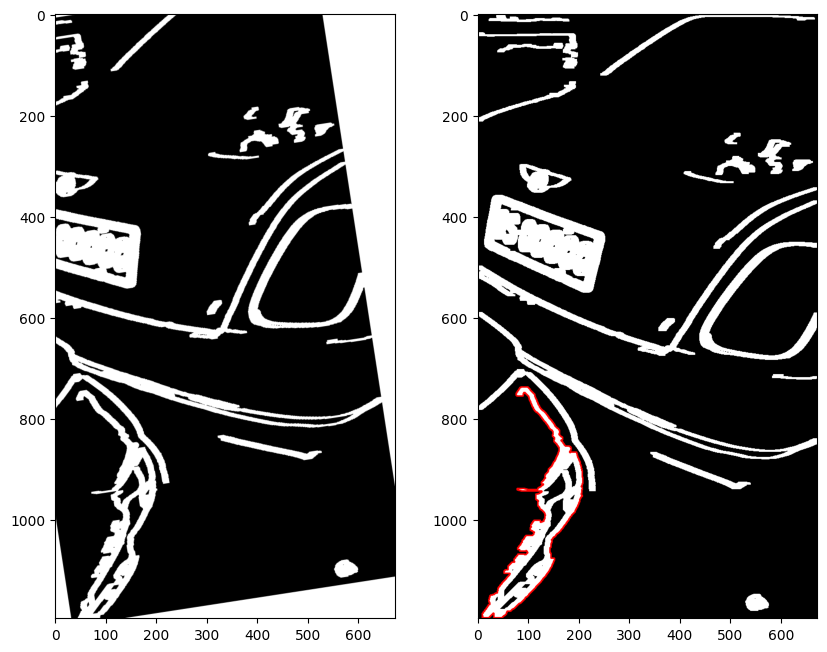

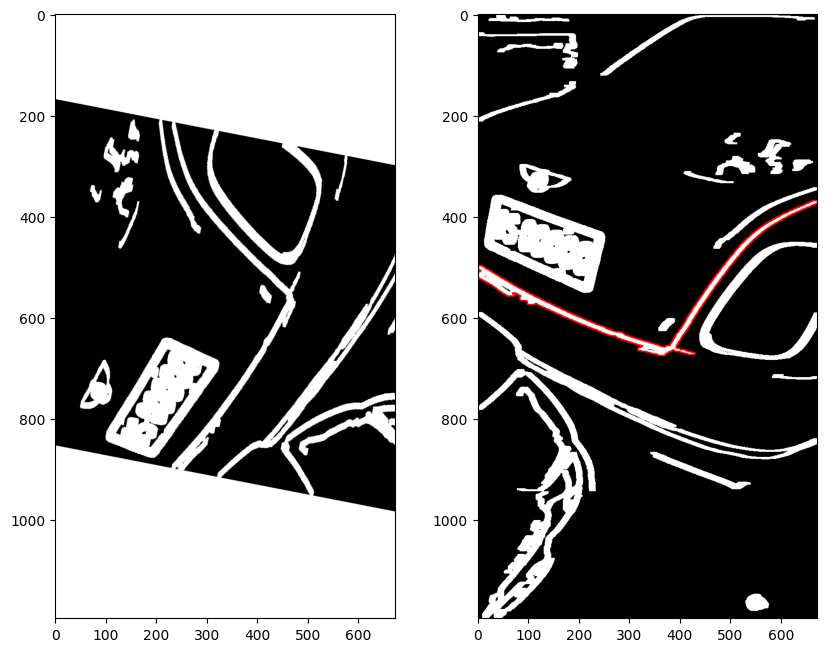

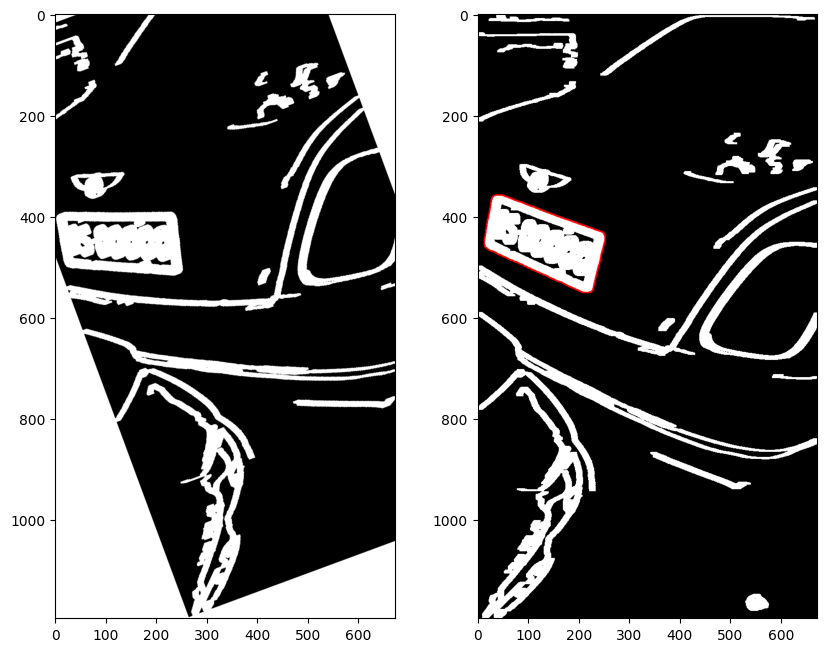

In [162]:
img5 = np.copy(img3)
rows, cols = img5.shape

cont_idx = 0

for cnt in contours:
    cont_idx += 1
    rect = cv.minAreaRect(cnt)
    w, h = rect[1]

    if w < 50 or h < 50:
        continue
    r = w / h
    if r > 4 or r < 1 / 4:
        continue
    area = cv.contourArea(cnt)
    if area < 10000:
        continue
    area2 = w * h

    M = cv.getRotationMatrix2D(rect[0], rect[-1], 1)

    img6 = cv.warpAffine(img5, M, (cols, rows), borderValue=[255, 255, 255])

    box = cv.boxPoints(rect)
    box = np.int64(box)

    bgr_img = cv.cvtColor(img5, cv.COLOR_GRAY2BGR)

    cv.drawContours(bgr_img, contours, contourIdx=cont_idx - 1, color=[0, 0, 255], thickness=2)

    fig, axex = plt.subplots(1, 2, figsize=(10, 8), dpi=100)
    axex[0].imshow(img6, cmap='gray')
    axex[1].imshow(bgr_img[:, :, ::-1])

    plt.show()